118 images × 39209 neurons
ViT logits shape: (118, 1000)
Areas shape: (39209,)
Softmax probabilities:
  shape: (118, 1000)
  min: 6.8413453e-09
  max: 0.99957424
  row sums: [0.99999994 0.99999976 1.0000002  0.99999994 0.9999997 ]

NMF:
  W shape: (118, 10)
  H shape: (10, 1000)
  reconstruction error: 5.2416306

Top ImageNet class indices per NMF component:

Component 0
  class  291  weight=1.302263
  class  347  weight=0.015546
  class  345  weight=0.003884
  class  293  weight=0.003291
  class  346  weight=0.002137
  class  286  weight=0.001429
  class  353  weight=0.000971
  class  351  weight=0.000780
  class  276  weight=0.000728
  class  352  weight=0.000705

Component 1
  class  146  weight=1.272146
  class  144  weight=0.026753
  class   99  weight=0.009623
  class  132  weight=0.007828
  class  129  weight=0.007701
  class  128  weight=0.006410
  class  134  weight=0.005095
  class  127  weight=0.004133
  class   21  weight=0.004026
  class  100  weight=0.001539

Component 2


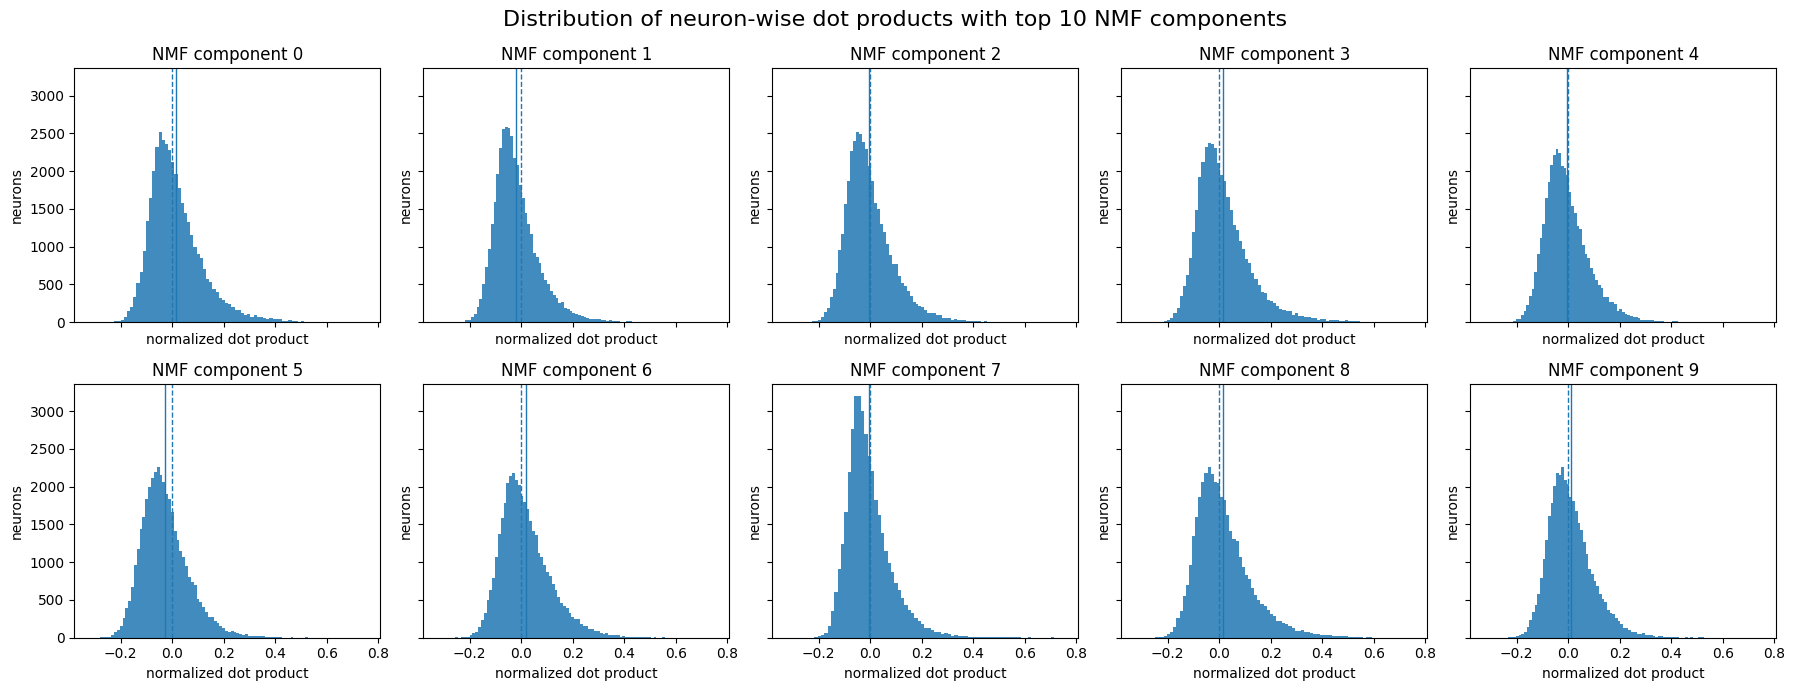

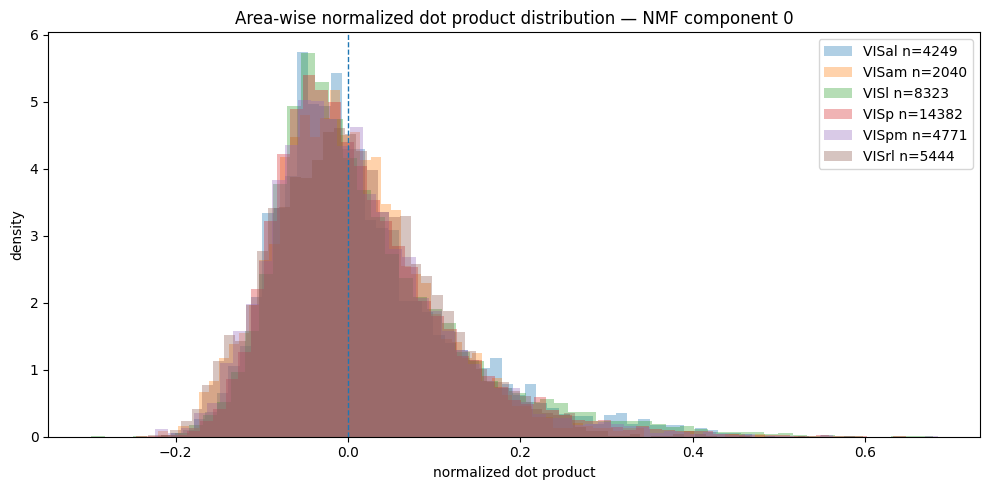

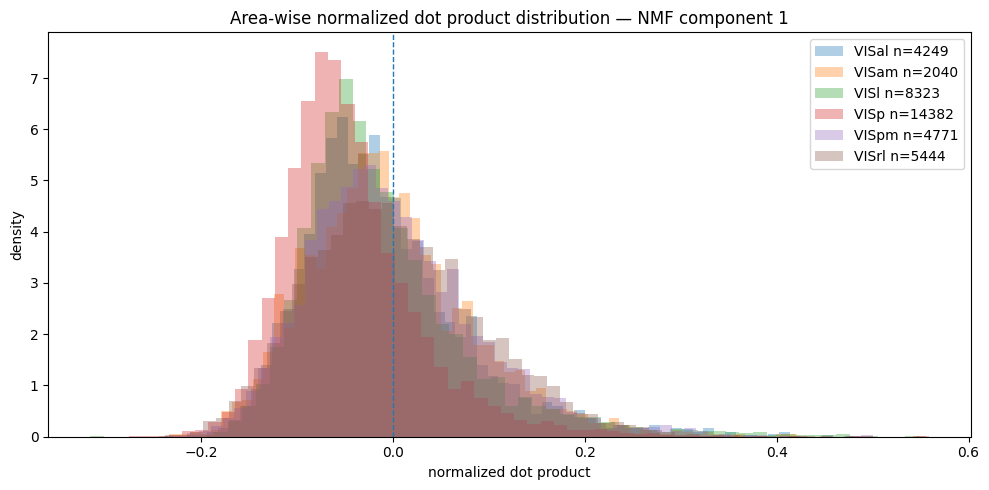

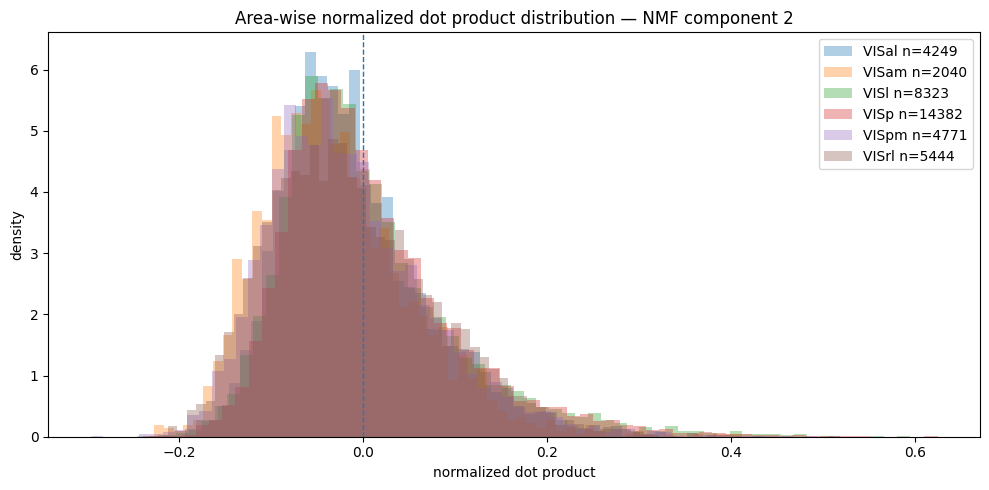

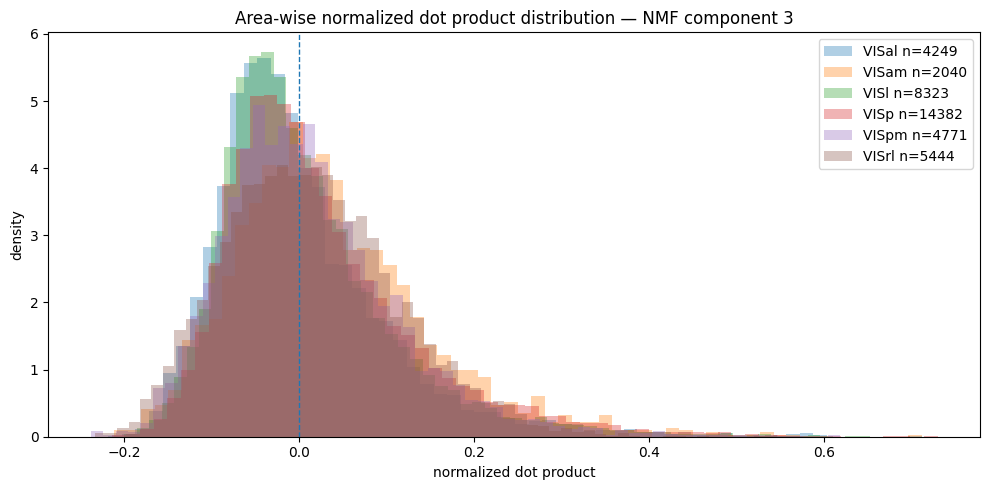

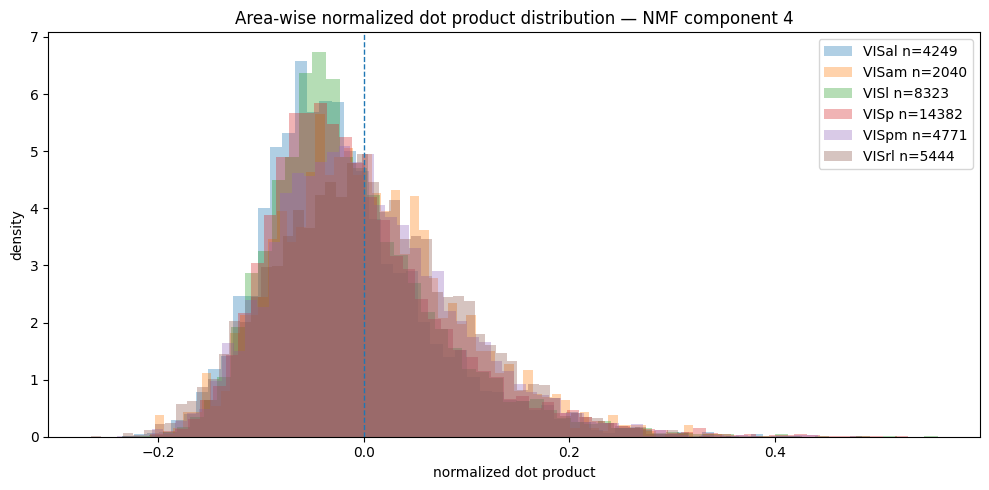

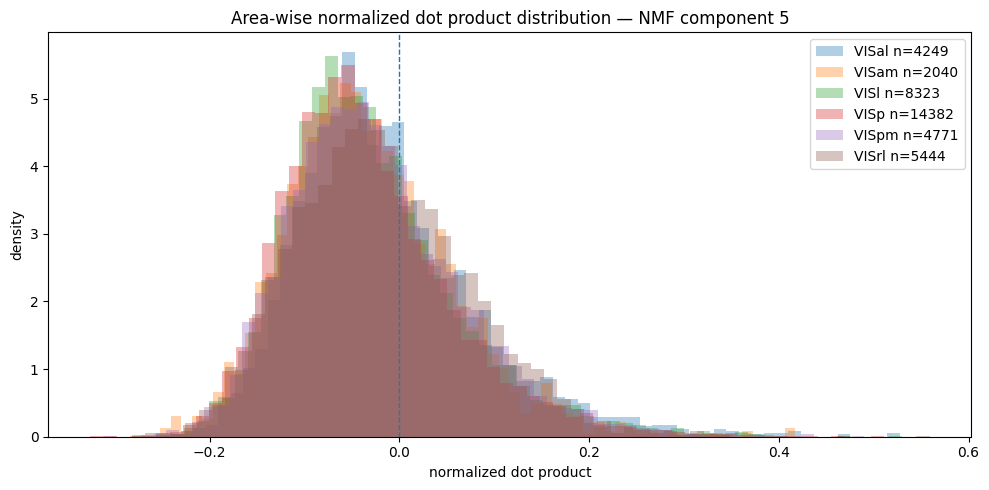

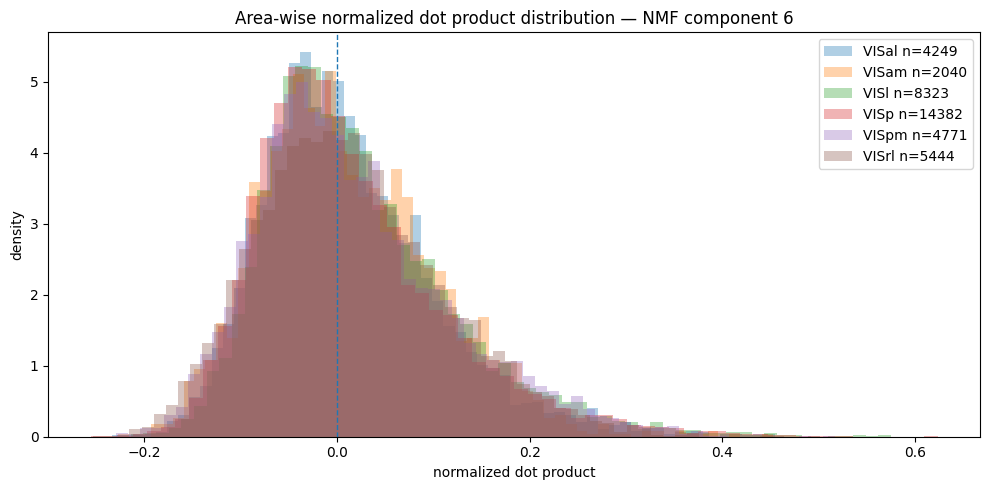

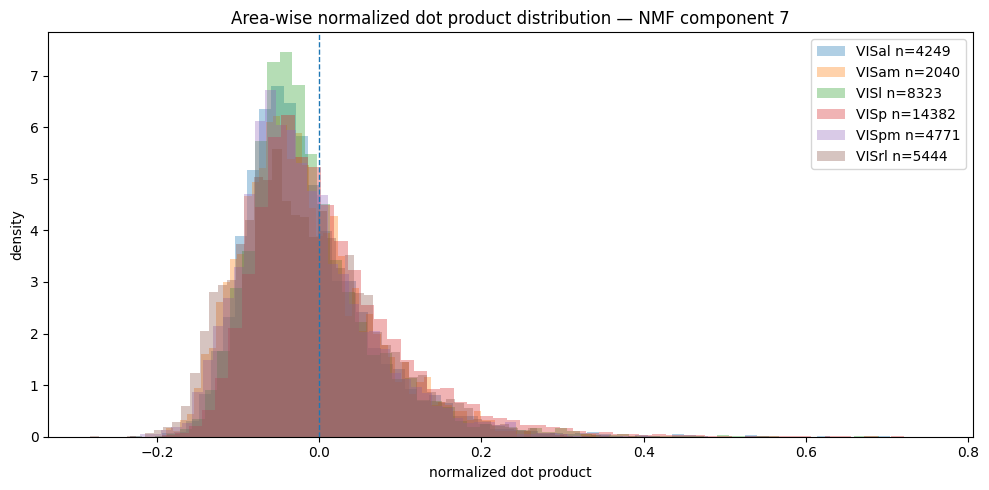

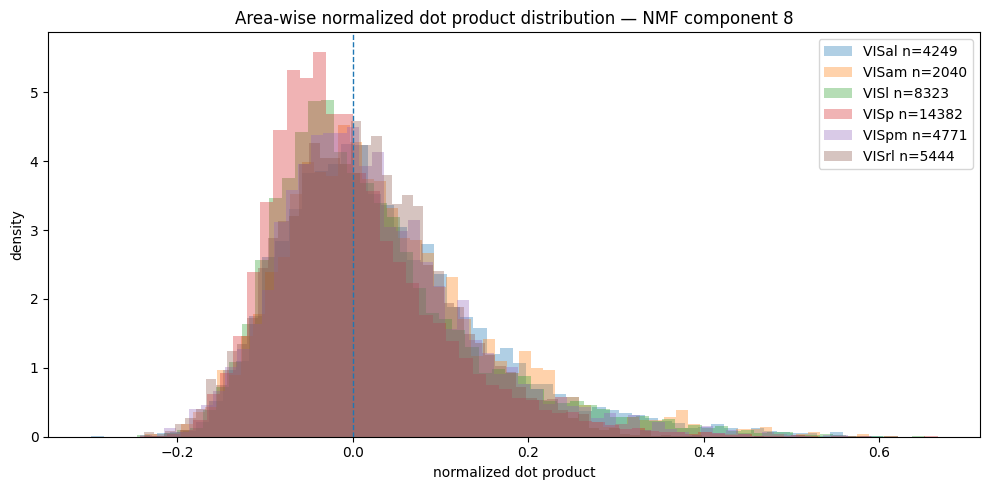

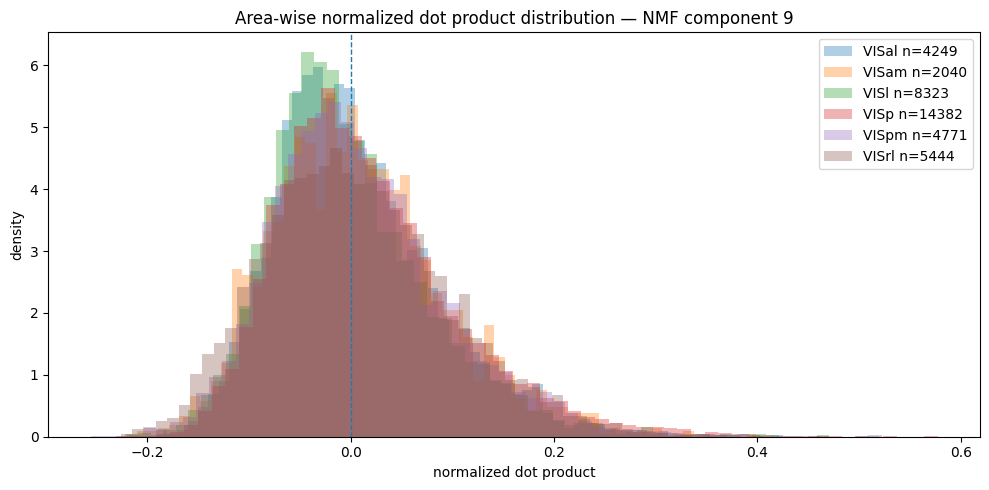


Top neurons per NMF component by normalized dot product:

Component 0
  rank  1 | neuron  3293 | area=VISpm | dot=0.6844
  rank  2 | neuron 13892 | area=VISl | dot=0.6789
  rank  3 | neuron 12385 | area=VISl | dot=0.6502
  rank  4 | neuron  1272 | area=VISp | dot=0.6475
  rank  5 | neuron 26524 | area=VISl | dot=0.6345
  rank  6 | neuron  1085 | area=VISl | dot=0.5940
  rank  7 | neuron  4410 | area=VISal | dot=0.5885
  rank  8 | neuron   600 | area=VISp | dot=0.5880
  rank  9 | neuron 10491 | area=VISp | dot=0.5745
  rank 10 | neuron 18018 | area=VISl | dot=0.5723
  rank 11 | neuron 24197 | area=VISl | dot=0.5700
  rank 12 | neuron  7030 | area=VISp | dot=0.5625
  rank 13 | neuron 12506 | area=VISpm | dot=0.5624
  rank 14 | neuron 10613 | area=VISl | dot=0.5623
  rank 15 | neuron 18008 | area=VISl | dot=0.5582
  rank 16 | neuron  1114 | area=VISl | dot=0.5537
  rank 17 | neuron 32649 | area=VISp | dot=0.5517
  rank 18 | neuron  8014 | area=VISpm | dot=0.5511
  rank 19 | neuron   298 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import NMF
from sklearn.preprocessing import StandardScaler

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = "/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl"
NEURAL_PATH = "/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy"
AREAS_PATH  = "/home/maria/ProjectionSort/data/brain_area.npy"

# ============================================================
# HELPERS
# ============================================================

def softmax(x, axis=-1):
    """Numerically stable softmax."""
    x = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)


def l2_normalize_columns(X, eps=1e-12):
    """Normalize columns of matrix X to unit L2 norm."""
    norms = np.linalg.norm(X, axis=0, keepdims=True)
    return X / (norms + eps)


# ============================================================
# LOAD DATA
# ============================================================

vit_obj = np.load(VIT_PATH, allow_pickle=True)
vit = vit_obj["natural_scenes"]          # (images, 1000)

R = np.load(NEURAL_PATH).T               # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)

n_images, n_neurons = R.shape

print(f"{n_images} images × {n_neurons} neurons")
print(f"ViT logits shape: {vit.shape}")
print(f"Areas shape: {areas.shape}")

assert vit.shape[0] == R.shape[0], "ViT images and neural responses must have same image dimension."
assert areas.shape[0] == R.shape[1], "Areas must have one label per neuron."

# ============================================================
# SOFTMAX LOGITS
# ============================================================

P = softmax(vit, axis=1)                 # (images, 1000)

print("Softmax probabilities:")
print("  shape:", P.shape)
print("  min:", P.min())
print("  max:", P.max())
print("  row sums:", P.sum(axis=1)[:5])

# ============================================================
# NMF ON SOFTMAX PROBABILITIES
# ============================================================

n_components = 10

nmf = NMF(
    n_components=n_components,
    init="nndsvda",
    solver="cd",
    beta_loss="frobenius",
    max_iter=2000,
    tol=1e-5,
    random_state=0,
)

W = nmf.fit_transform(P)                 # (images, components)
H = nmf.components_                      # (components, classes)

print("\nNMF:")
print("  W shape:", W.shape)
print("  H shape:", H.shape)
print("  reconstruction error:", nmf.reconstruction_err_)

# ============================================================
# COMPONENT INTERPRETATION: TOP IMAGENET CLASSES PER COMPONENT
# ============================================================

top_k_classes = 10

print("\nTop ImageNet class indices per NMF component:")
for k in range(n_components):
    top_idx = np.argsort(H[k])[::-1][:top_k_classes]
    top_weights = H[k, top_idx]

    print(f"\nComponent {k}")
    for idx, weight in zip(top_idx, top_weights):
        print(f"  class {idx:4d}  weight={weight:.6f}")

# ============================================================
# DOT PRODUCTS WITH NEURAL DATA
# ============================================================
#
# W[:, k] is the activation of NMF component k across images.
# R[:, j] is the response of neuron j across images.
#
# Dot product over images:
#
#     dot[k, j] = sum_i W[i, k] * R[i, j]
#
# This asks: does neuron j respond strongly to images where component k is active?
#
# We compute two versions:
#
# 1. raw_dot:
#    Uses raw component activations and raw neural responses.
#
# 2. normalized_dot:
#    Z-score neural responses across images.
#    Z-score NMF component activations across images.
#    Then L2-normalize columns.
#
#    This makes the dot product cosine-like, removing magnitude effects.
# ============================================================

raw_dot = W.T @ R                         # (components, neurons)

# Z-score over images
W_z = StandardScaler().fit_transform(W)   # (images, components)
R_z = StandardScaler().fit_transform(R)   # (images, neurons)

# L2-normalize across images
W_unit = l2_normalize_columns(W_z)
R_unit = l2_normalize_columns(R_z)

normalized_dot = W_unit.T @ R_unit        # (components, neurons)

print("\nDot products:")
print("  raw_dot shape:", raw_dot.shape)
print("  normalized_dot shape:", normalized_dot.shape)

for k in range(n_components):
    vals = normalized_dot[k]
    print(
        f"Component {k}: "
        f"mean={vals.mean():.4f}, "
        f"std={vals.std():.4f}, "
        f"min={vals.min():.4f}, "
        f"max={vals.max():.4f}"
    )

# ============================================================
# PLOT DISTRIBUTION OF DOT PRODUCTS
# ============================================================

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True, sharey=True)
axes = axes.ravel()

for k, ax in enumerate(axes):
    vals = normalized_dot[k]

    ax.hist(vals, bins=80, alpha=0.85)
    ax.axvline(0, linestyle="--", linewidth=1)
    ax.axvline(vals.mean(), linestyle="-", linewidth=1)

    ax.set_title(f"NMF component {k}")
    ax.set_xlabel("normalized dot product")
    ax.set_ylabel("neurons")

fig.suptitle(
    "Distribution of neuron-wise dot products with top 10 NMF components",
    fontsize=16,
)
plt.tight_layout()
plt.show()

# ============================================================
# OPTIONAL: AREA-WISE DISTRIBUTIONS
# ============================================================

unique_areas = np.unique(areas)

for k in range(n_components):
    plt.figure(figsize=(10, 5))

    for area in unique_areas:
        mask = areas == area
        vals = normalized_dot[k, mask]

        plt.hist(
            vals,
            bins=60,
            alpha=0.35,
            density=True,
            label=f"{area} n={mask.sum()}",
        )

    plt.axvline(0, linestyle="--", linewidth=1)
    plt.title(f"Area-wise normalized dot product distribution — NMF component {k}")
    plt.xlabel("normalized dot product")
    plt.ylabel("density")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ============================================================
# TOP NEURONS PER COMPONENT
# ============================================================

top_k_neurons = 20

print("\nTop neurons per NMF component by normalized dot product:")

for k in range(n_components):
    vals = normalized_dot[k]
    top_neurons = np.argsort(vals)[::-1][:top_k_neurons]

    print(f"\nComponent {k}")
    for rank, neuron_idx in enumerate(top_neurons, start=1):
        print(
            f"  rank {rank:2d} | "
            f"neuron {neuron_idx:5d} | "
            f"area={areas[neuron_idx]} | "
            f"dot={vals[neuron_idx]:.4f}"
        )

# ============================================================
# SAVE RESULTS
# ============================================================

out = {
    "probabilities": P,
    "nmf_W_image_components": W,
    "nmf_H_class_components": H,
    "raw_dot": raw_dot,
    "normalized_dot": normalized_dot,
    "areas": areas,
    "reconstruction_error": nmf.reconstruction_err_,
}

np.savez(
    "/home/maria/ProjectionSort/data/nmf_softmax_neural_dot_products.npz",
    **out,
)

print("\nSaved:")
print("/home/maria/ProjectionSort/data/nmf_softmax_neural_dot_products.npz")

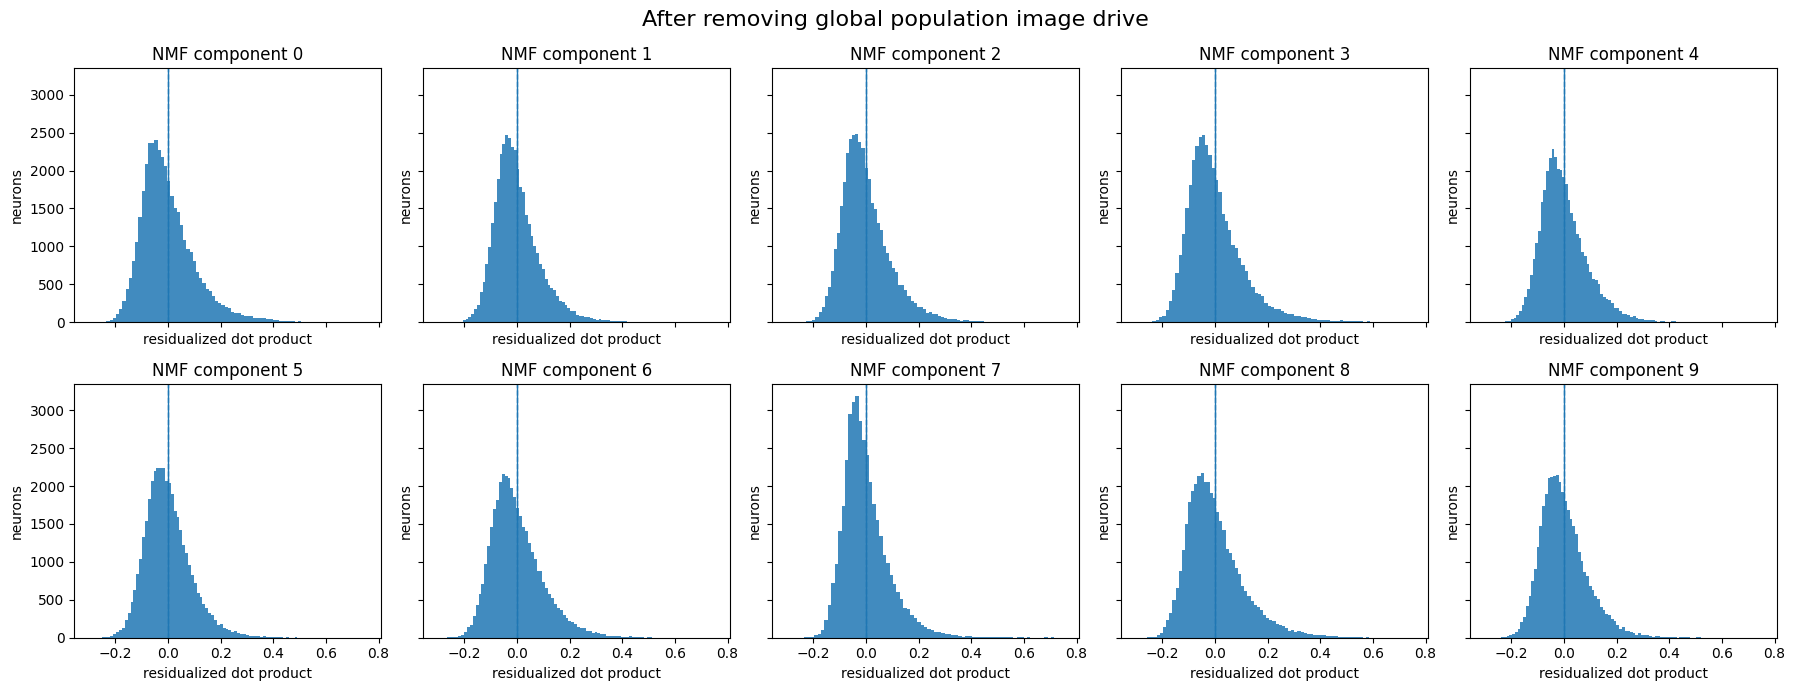

In [3]:
# R_z: images × neurons
# population_mean: images,

population_mean = R_z.mean(axis=1, keepdims=True)

# regress population mean out of every neuron
X = population_mean
beta = np.linalg.pinv(X) @ R_z
R_resid = R_z - X @ beta

# renormalize residualized responses
R_resid_unit = R_resid / (np.linalg.norm(R_resid, axis=0, keepdims=True) + 1e-12)

normalized_dot_resid = W_unit.T @ R_resid_unit

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True, sharey=True)
axes = axes.ravel()

for k, ax in enumerate(axes):
    vals = normalized_dot_resid[k]

    ax.hist(vals, bins=80, alpha=0.85)
    ax.axvline(0, linestyle="--", linewidth=1)
    ax.axvline(vals.mean(), linestyle="-", linewidth=1)
    ax.set_title(f"NMF component {k}")
    ax.set_xlabel("residualized dot product")
    ax.set_ylabel("neurons")

fig.suptitle("After removing global population image drive", fontsize=16)
plt.tight_layout()
plt.show()

Null dots shape: (1000, 10, 39209)


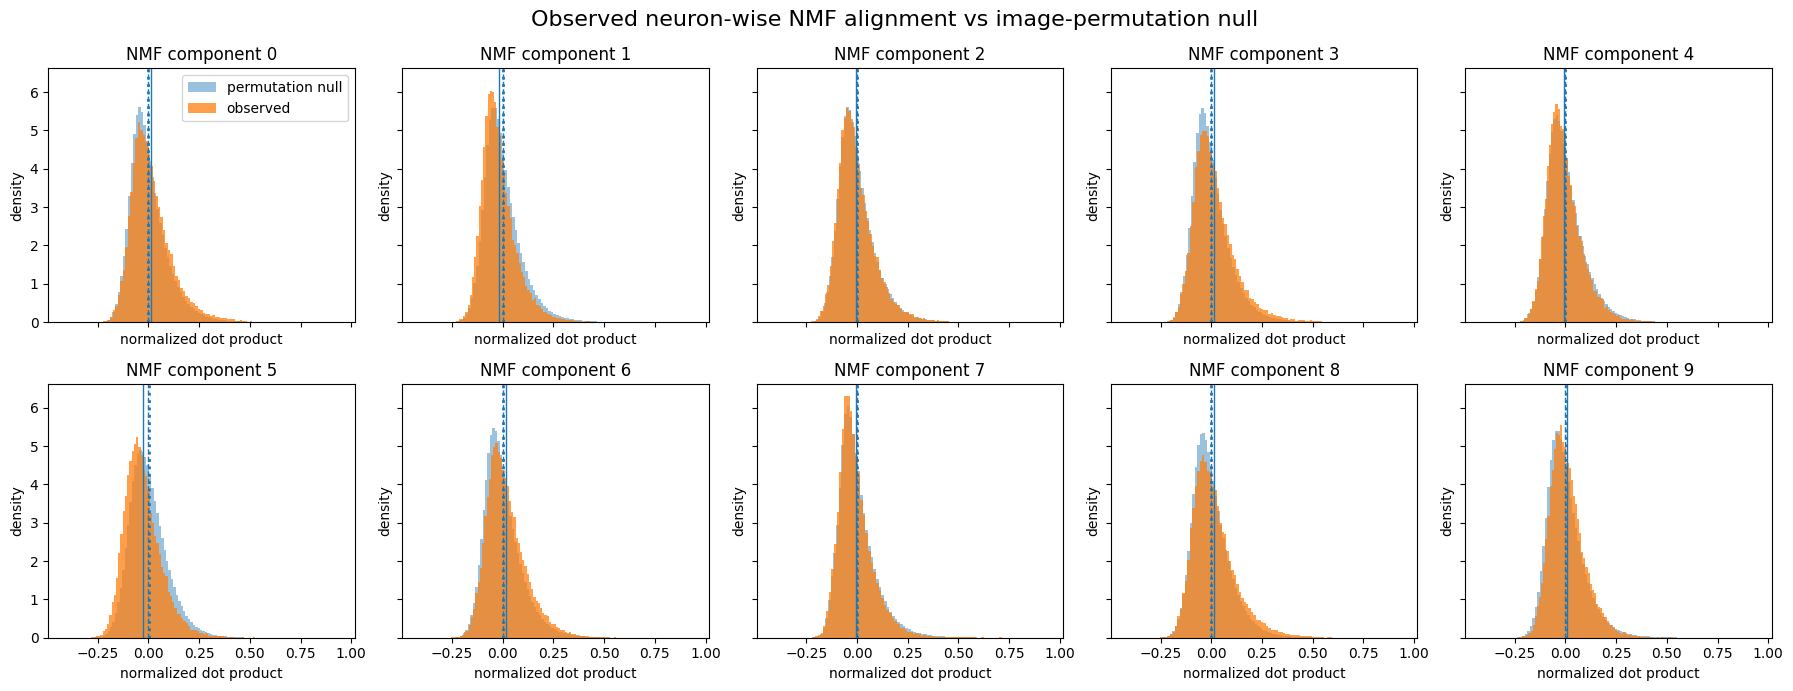

In [4]:
# ============================================================
# PERMUTATION NULL FOR NMF-NEURAL DOT PRODUCTS
# ============================================================

n_shuffles = 1000
rng = np.random.default_rng(0)

# Store null dot products:
# shape = (shuffles, components, neurons)
null_dots = np.empty((n_shuffles, n_components, n_neurons), dtype=np.float32)

for s in range(n_shuffles):
    perm = rng.permutation(n_images)

    # Break image-wise correspondence between semantic component activations
    # and neural responses.
    W_perm = W_unit[perm, :]

    null_dots[s] = W_perm.T @ R_unit

print("Null dots shape:", null_dots.shape)

# Flatten null over shuffles and neurons per component
null_flat = null_dots.reshape(n_shuffles, n_components, n_neurons)

# ============================================================
# OBSERVED VS NULL HISTOGRAMS PER COMPONENT
# ============================================================

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True, sharey=True)
axes = axes.ravel()

for k, ax in enumerate(axes):
    obs = normalized_dot[k]              # (neurons,)
    null = null_flat[:, k, :].ravel()    # (shuffles * neurons,)

    ax.hist(
        null,
        bins=100,
        density=True,
        alpha=0.45,
        label="permutation null",
    )

    ax.hist(
        obs,
        bins=80,
        density=True,
        alpha=0.75,
        label="observed",
    )

    ax.axvline(0, linestyle="--", linewidth=1)
    ax.axvline(obs.mean(), linestyle="-", linewidth=1)
    ax.axvline(null.mean(), linestyle=":", linewidth=2)

    ax.set_title(f"NMF component {k}")
    ax.set_xlabel("normalized dot product")
    ax.set_ylabel("density")

axes[0].legend()

fig.suptitle(
    "Observed neuron-wise NMF alignment vs image-permutation null",
    fontsize=16,
)
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# COMPONENT-LEVEL SUMMARY AGAINST NULL
# ============================================================

for k in range(n_components):
    obs = normalized_dot[k]
    null = null_flat[:, k, :].ravel()

    obs_mean = obs.mean()
    null_mean = null.mean()
    null_std = null.std()

    obs_q01, obs_q05, obs_q50, obs_q95, obs_q99 = np.quantile(
        obs, [0.01, 0.05, 0.50, 0.95, 0.99]
    )

    null_q01, null_q05, null_q50, null_q95, null_q99 = np.quantile(
        null, [0.01, 0.05, 0.50, 0.95, 0.99]
    )

    frac_obs_above_null_99 = np.mean(obs > null_q99)
    frac_obs_below_null_01 = np.mean(obs < null_q01)

    print(f"\nComponent {k}")
    print(f"  observed mean: {obs_mean:.5f}")
    print(f"  null mean:     {null_mean:.5f}")
    print(f"  null std:      {null_std:.5f}")

    print("  observed quantiles:")
    print(
        f"    1%={obs_q01:.4f}, 5%={obs_q05:.4f}, "
        f"50%={obs_q50:.4f}, 95%={obs_q95:.4f}, 99%={obs_q99:.4f}"
    )

    print("  null quantiles:")
    print(
        f"    1%={null_q01:.4f}, 5%={null_q05:.4f}, "
        f"50%={null_q50:.4f}, 95%={null_q95:.4f}, 99%={null_q99:.4f}"
    )

    print(f"  fraction observed > null 99%: {frac_obs_above_null_99:.4f}")
    print(f"  fraction observed < null 1%:  {frac_obs_below_null_01:.4f}")


Component 0
  observed mean: 0.01416
  null mean:     0.00003
  null std:      0.09239
  observed quantiles:
    1%=-0.1564, 5%=-0.1151, 50%=-0.0050, 95%=0.2085, 99%=0.3538
  null quantiles:
    1%=-0.1574, 5%=-0.1192, 50%=-0.0167, 95%=0.1737, 99%=0.2986
  fraction observed > null 99%: 0.0188
  fraction observed < null 1%:  0.0096

Component 1
  observed mean: -0.01892
  null mean:     -0.00026
  null std:      0.09228
  observed quantiles:
    1%=-0.1654, 5%=-0.1299, 50%=-0.0343, 95%=0.1427, 99%=0.2598
  null quantiles:
    1%=-0.1573, 5%=-0.1193, 50%=-0.0170, 95%=0.1730, 99%=0.2984
  fraction observed > null 99%: 0.0061
  fraction observed < null 1%:  0.0150

Component 2
  observed mean: -0.00323
  null mean:     -0.00064
  null std:      0.09230
  observed quantiles:
    1%=-0.1602, 5%=-0.1222, 50%=-0.0194, 95%=0.1687, 99%=0.2900
  null quantiles:
    1%=-0.1576, 5%=-0.1197, 50%=-0.0174, 95%=0.1729, 99%=0.2975
  fraction observed > null 99%: 0.0089
  fraction observed < null 1%:  0

In [6]:
for k in [0, 3, 5, 8]:
    top_images = np.argsort(W[:, k])[::-1][:10]
    print(f"\nComponent {k} top images:", top_images)


Component 0 top images: [ 6  7  5 46 45 44 15 92 97 96]

Component 3 top images: [17 22 16 39 15 13 47 97 45 44]

Component 5 top images: [ 80  98  62  96 103  99  88  30  59  20]

Component 8 top images: [ 19  18  35  55 109  24  21  51  28 102]
